# Research Centre Quality Classification

This notebook analyses research centre infrastructure data, groups centres into quality tiers using K-Means clustering.

The dataset contains features describing internal facilities and surrounding healthcare access for research centres across several cities. The goal is to identify natural groupings that correspond to infrastructure quality, without predefined labels.

## Approach

- Exploratory data analysis of infrastructure and access features
- Feature selection based on domain relevance and correlation
- K-Means clustering with k chosen via the elbow method
- Programmatic tier mapping derived from cluster characteristics

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Load data

In [5]:
data_path = Path("research_centers.csv")
df = pd.read_csv(data_path)
df.head()

,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983


In [6]:
print(f"Shape: {df.shape}")
df.describe()

Shape: (50, 10)


,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,50.542770,-1.554638,5.660000,1.860000,2.240000,0.568843,0.321164
std,0.320289,0.253853,3.146816,1.340271,1.684988,0.249511,0.182562
min,50.007100,-1.976900,1.000000,0.000000,0.000000,0.119515,0.056541
25%,50.240375,-1.747225,3.000000,1.000000,1.000000,0.344145,0.173814
50%,50.635350,-1.561000,5.000000,2.000000,2.000000,0.585503,0.297584
75%,50.831475,-1.374175,8.750000,3.000000,3.000000,0.800489,0.476387
max,50.994600,-1.049300,11.000000,4.000000,5.000000,0.992984,0.697016


In [7]:
df.isnull().sum()

researchCenterId           0
researchCenterName         0
city                       0
latitude                   0
longitude                  0
internalFacilitiesCount    0
hospitals_10km             0
pharmacies_10km            0
facilityDiversity_10km     0
facilityDensity_10km       0
dtype: int64

## Exploratory Data Analysis

In [9]:
def plot_bar(x, y, title, ylabel, figsize=(10, 4)):
    plt.figure(figsize=figsize)
    plt.bar(x, y, edgecolor="k", color="dodgerblue")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

### Research centres per city

Cities: ['City 1' 'City 2' 'City 3' 'City 4' 'City 5']
Count:  5


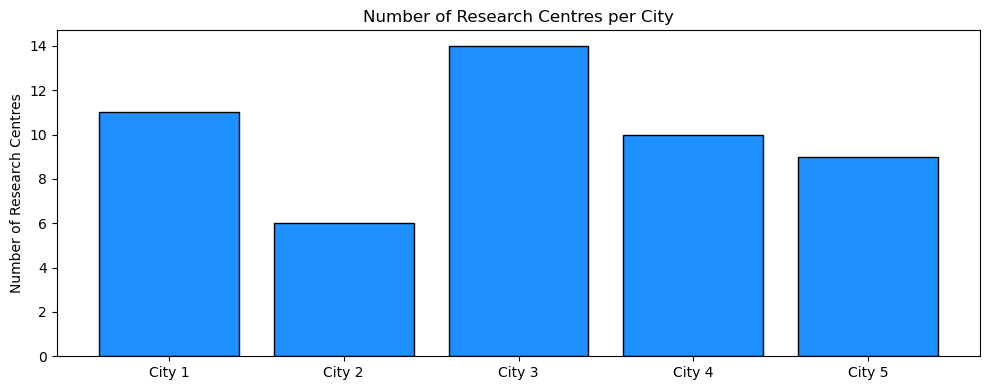

In [11]:
number_of_cities = np.sort(df["city"].unique())
print(f"Cities: {number_of_cities}")
print(f"Count:  {number_of_cities.size}")

df_res_centre = df.groupby("city").size()
plot_bar(
    number_of_cities,
    df_res_centre,
    "Number of Research Centres per City",
    "Number of Research Centres",
)

### Internal facilities distribution

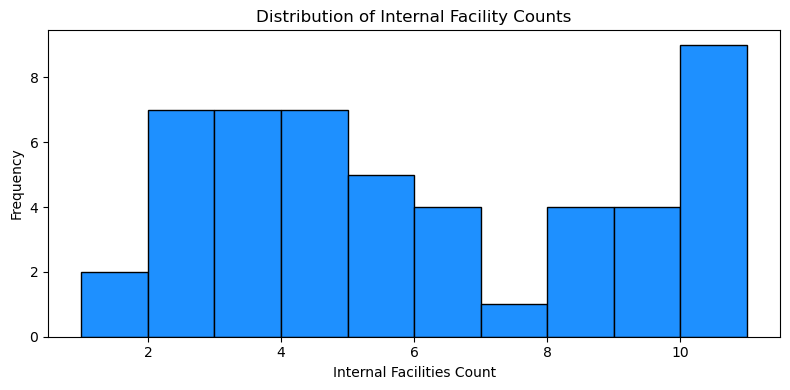

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(df["internalFacilitiesCount"], edgecolor="k", color="dodgerblue")
plt.xlabel("Internal Facilities Count")
plt.ylabel("Frequency")
plt.title("Distribution of Internal Facility Counts")
plt.tight_layout()
plt.show()

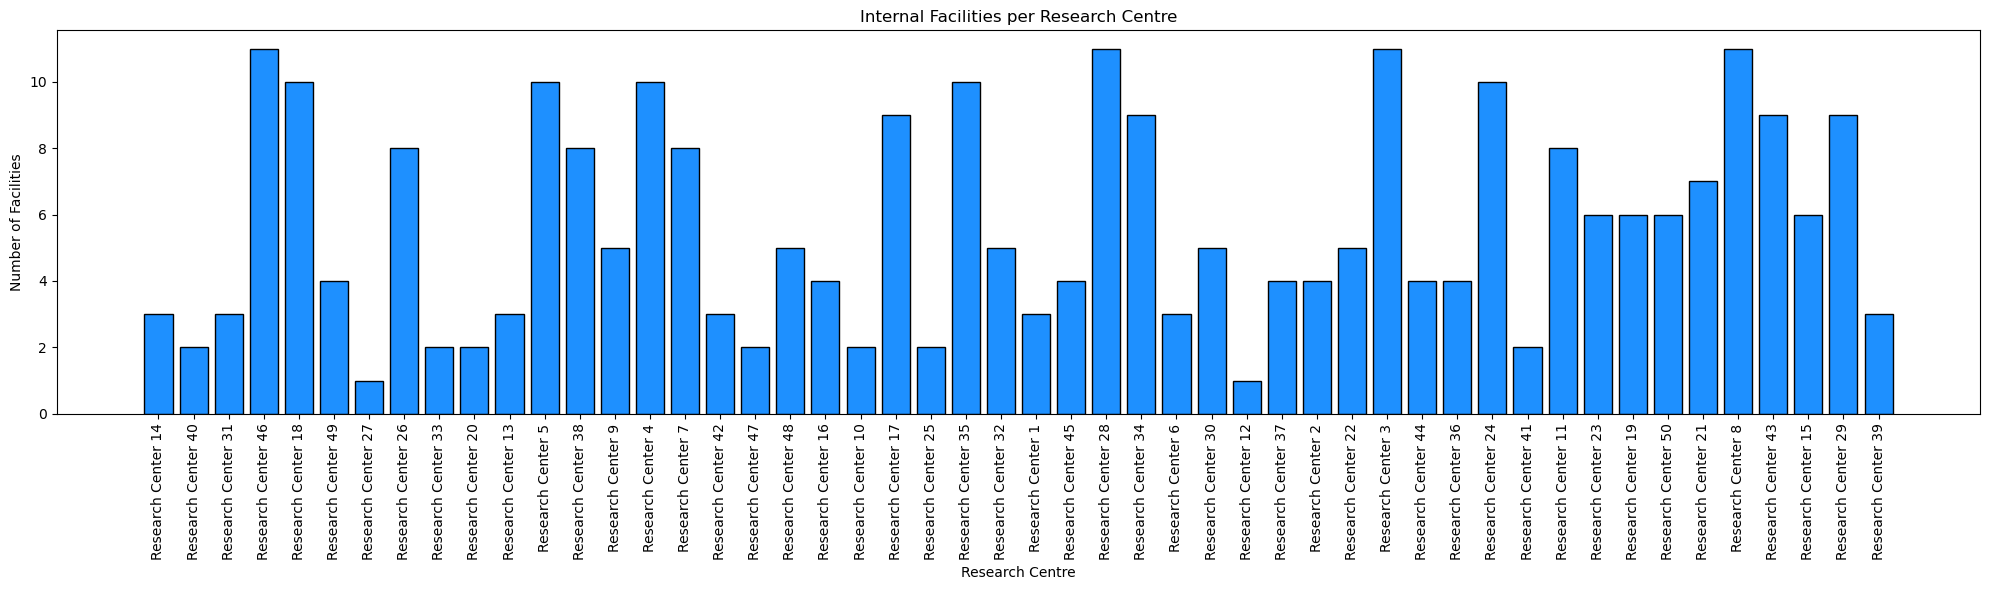

In [14]:
plt.figure(figsize=(20, 6))
plt.bar(df["researchCenterName"], df["internalFacilitiesCount"],
        edgecolor="k", color="dodgerblue")
plt.xlabel("Research Centre")
plt.ylabel("Number of Facilities")
plt.title("Internal Facilities per Research Centre")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Infrastructure features by city

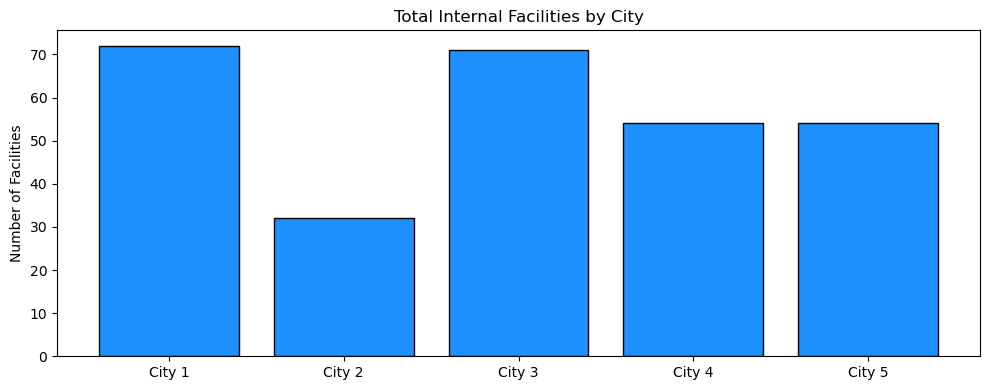

In [16]:
facilities_per_city = df.groupby("city")["internalFacilitiesCount"].sum().reset_index()
plot_bar(
    facilities_per_city["city"],
    facilities_per_city["internalFacilitiesCount"],
    "Total Internal Facilities by City",
    "Number of Facilities",
)

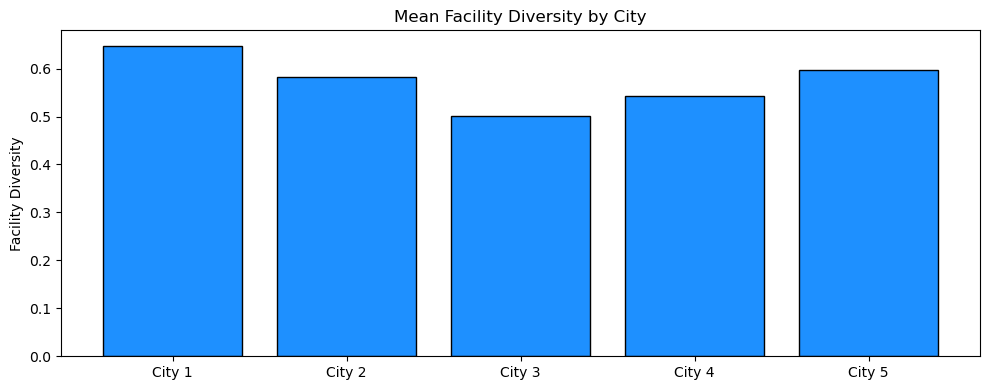

In [17]:
fac_diversity_per_city = df.groupby("city")["facilityDiversity_10km"].mean().reset_index()
plot_bar(
    fac_diversity_per_city["city"],
    fac_diversity_per_city["facilityDiversity_10km"],
    "Mean Facility Diversity by City",
    "Facility Diversity",
)

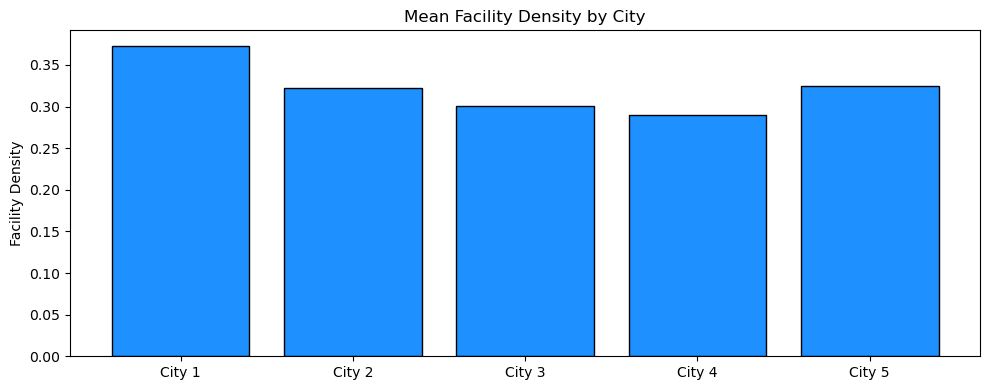

In [18]:
fac_density_per_city = df.groupby("city")["facilityDensity_10km"].mean().reset_index()
plot_bar(
    fac_density_per_city["city"],
    fac_density_per_city["facilityDensity_10km"],
    "Mean Facility Density by City",
    "Facility Density",
)

### Healthcare access by city

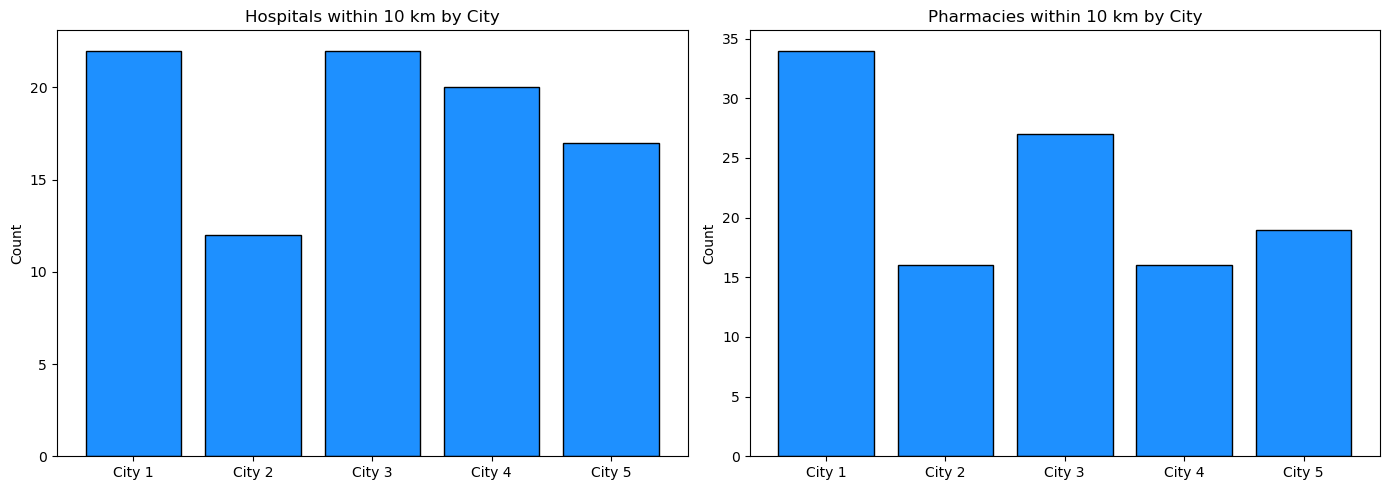

In [20]:
hospitals_per_city    = df.groupby("city")["hospitals_10km"].sum().reset_index()
pharmacies_per_city   = df.groupby("city")["pharmacies_10km"].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hospitals_per_city["city"], hospitals_per_city["hospitals_10km"],
            edgecolor="k", color="dodgerblue")
axes[0].set_title("Hospitals within 10 km by City")
axes[0].set_ylabel("Count")

axes[1].bar(pharmacies_per_city["city"], pharmacies_per_city["pharmacies_10km"],
            edgecolor="k", color="dodgerblue")
axes[1].set_title("Pharmacies within 10 km by City")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Feature Selection

The dataset contains a mix of numeric and non-numeric columns. Geographic coordinates (`longitude`, `latitude`) describe spatial location but carry no direct information about infrastructure quality and are excluded.

The five features retained for clustering are:

- `internalFacilitiesCount`: number of internal facilities; a direct proxy for centre capacity
- `hospitals_10km` and `pharmacies_10km`: nearby healthcare access
- `facilityDiversity_10km`: variety of facility types in the surrounding area
- `facilityDensity_10km`: density of external facilities within 10 km

These variables capture both internal infrastructure and the external environment that supports centre operations.

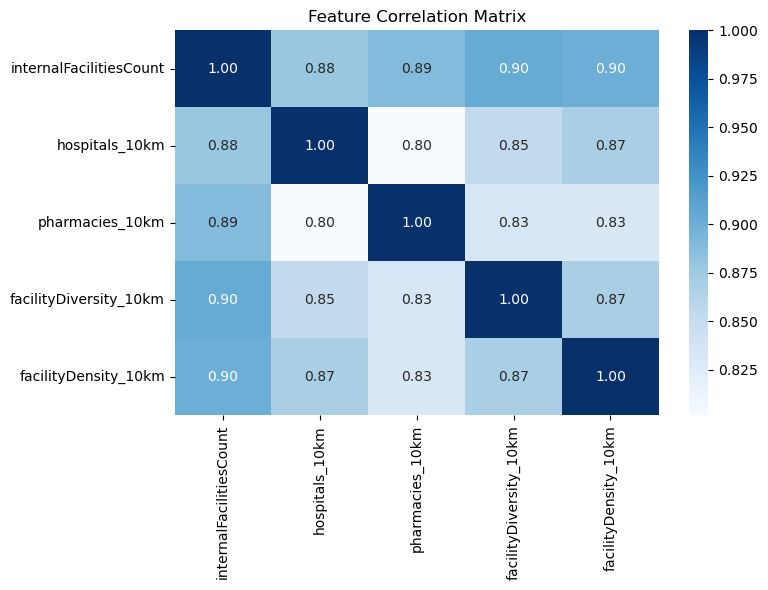

In [22]:
features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km",
]

correlation = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="Blues", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

The strongest correlations with `facilityDiversity_10km` are `internalFacilitiesCount` (0.90), `facilityDensity_10km` (0.87), and `hospitals_10km` (0.85). This indicates that centres with higher internal capacity tend to sit in areas with denser and more diverse surrounding infrastructure.

All five features are retained, as each contributes a distinct aspect of the quality signal. The correlations among size-related features (internal count, density, diversity) mean their shared variance is slightly over-weighted in the Euclidean distance K-Means optimises, a known limitation worth noting.

## Choosing k: the Elbow Method

Before fitting the final model, we assess the appropriate number of clusters by plotting inertia (within-cluster sum of squares) against k. The point where improvement slows sharply (the elbow) suggests a natural choice.

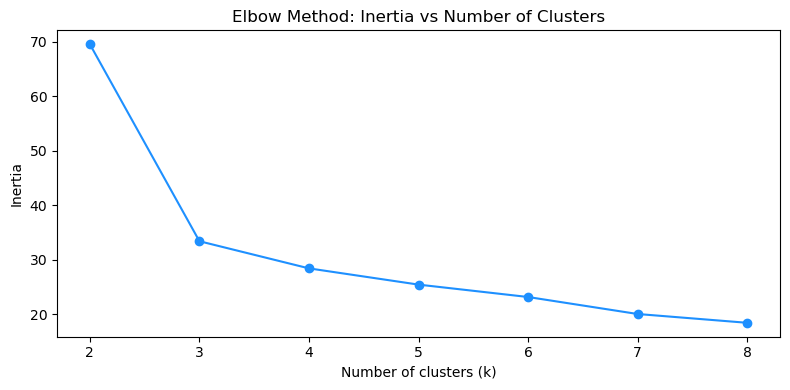

In [25]:
# Temporary scaler for elbow analysis only
_scaler = StandardScaler()
X_scaled_temp = _scaler.fit_transform(df[features])

inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_temp)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, marker="o", color="dodgerblue")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method: Inertia vs Number of Clusters")
plt.tight_layout()
plt.show()

The elbow at k = 3 is consistent with the domain framing of three quality tiers (Basic, Standard, Premium). The silhouette score below confirms this choice gives reasonable cluster separation.

## Clustering

A single `Pipeline` combining `StandardScaler` and `KMeans` is fit once on the raw feature matrix. All downstream analysis, labels, cluster summaries, tier mapping, and the saved model, derives from this single fit.

In [28]:
X = df[features]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=3, random_state=42, n_init=10)),
])

pipeline.fit(X)

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=3, n_init=10, random_state=42))])

In [29]:
# Extract labels and scaled data from the fitted pipeline — single source of truth
labels  = pipeline.named_steps["kmeans"].labels_
X_scaled = pipeline.named_steps["scaler"].transform(X)

df["cluster"] = labels

In [30]:
# Cluster mean profiles (original feature scale for readability)
summary = df.groupby("cluster")[features].mean()
summary

,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
cluster,,,,,
0,4.941176,1.529412,2.058824,0.559935,0.289845
1,9.529412,3.470588,4.117647,0.850424,0.536852
2,2.312500,0.500000,0.437500,0.279126,0.125271


### Tier mapping

Rather than hardcoding cluster-to-tier assignments, the mapping is derived programmatically from the cluster centres in scaled feature space. Ranking clusters by their mean scaled value across all features weights each dimension equally, consistent with the distance metric K-Means optimises, and remains correct regardless of how cluster labels happen to be assigned in any given run.

In [32]:
centres = pd.DataFrame(
    pipeline.named_steps["kmeans"].cluster_centers_,
    columns=features,
)

overall_quality = centres.mean(axis=1)
ranks = overall_quality.rank(ascending=True).astype(int)
tier_labels = {1: "Basic", 2: "Standard", 3: "Premium"}
cluster_to_tier = {cluster: tier_labels[rank] for cluster, rank in ranks.items()}

print("Cluster-to-tier mapping:", cluster_to_tier)

Cluster-to-tier mapping: {0: 'Standard', 1: 'Premium', 2: 'Basic'}


In [33]:
df["qualityTier"] = df["cluster"].map(cluster_to_tier)
df.head()

,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km,cluster,qualityTier
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506,2,Basic
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965,2,Basic
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155,2,Basic
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016,1,Premium
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983,1,Premium


## Evaluation: Silhouette Score

The silhouette score measures how similar each sample is to its own cluster relative to the nearest other cluster. Values range from −1 to 1; scores above 0.5 suggest reasonable separation.

In [35]:
score = silhouette_score(X_scaled, labels)
print(f"Silhouette score: {score:.3f}")

Silhouette score: 0.552


## Interpretation

### Tier distribution by city

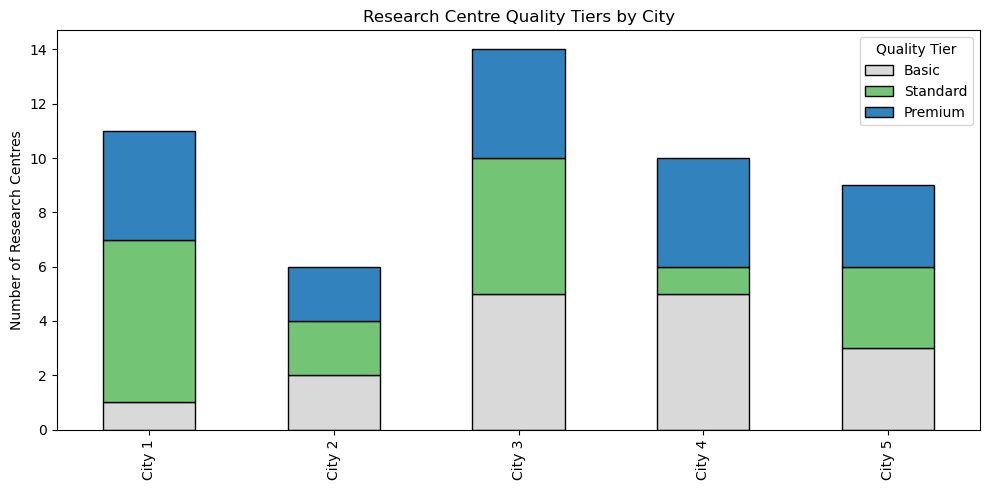

In [38]:
city_tier_counts = (
    df.groupby(["city", "qualityTier"])
    .size()
    .unstack(fill_value=0)
)

# Enforce consistent column order
for tier in ["Basic", "Standard", "Premium"]:
    if tier not in city_tier_counts.columns:
        city_tier_counts[tier] = 0
city_tier_counts = city_tier_counts[["Basic", "Standard", "Premium"]]

city_tier_counts.plot(
    kind="bar",
    stacked=True,
    cmap="tab20c_r",
    edgecolor="k",
    figsize=(10, 5),
)

plt.title("Research Centre Quality Tiers by City")
plt.xlabel("")
plt.ylabel("Number of Research Centres")
plt.legend(title="Quality Tier")
plt.tight_layout()
plt.show()

Premium centres are distributed fairly evenly across all cities. City 3 has the largest total number of centres; City 2 has the fewest. The tier mix varies by city, reflecting differences in local infrastructure quality rather than purely in research centre count.

### Facility diversity vs density by tier

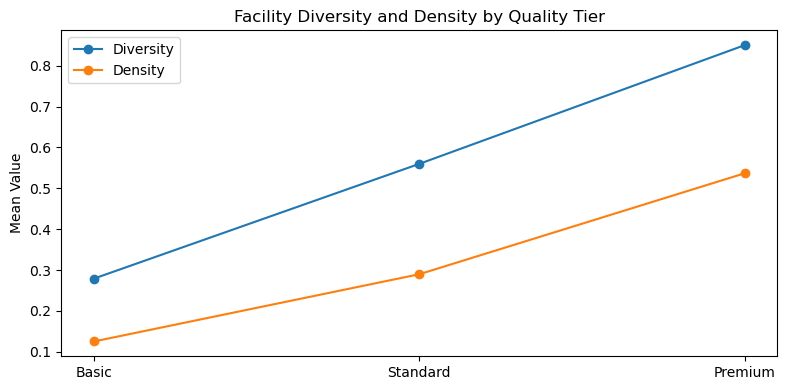

In [41]:
tier_order = ["Basic", "Standard", "Premium"]

tier_means = (
    df.groupby("qualityTier")[["facilityDiversity_10km", "facilityDensity_10km"]]
    .mean()
    .loc[tier_order]
)

x = range(len(tier_order))

plt.figure(figsize=(8, 4))
plt.plot(x, tier_means["facilityDiversity_10km"], marker="o", label="Diversity")
plt.plot(x, tier_means["facilityDensity_10km"],   marker="o", label="Density")
plt.xticks(x, tier_order)
plt.ylabel("Mean Value")
plt.title("Facility Diversity and Density by Quality Tier")
plt.legend()
plt.tight_layout()
plt.show()

Facility diversity shows a larger separation between tiers than density, suggesting it is the stronger differentiator of research centre quality in this dataset. Both features increase monotonically from Basic to Premium, consistent with the cluster structure identified by K-Means.